# TS5: Estimación espectral: Ancho de banda de señales reales
##  Catalina 

### Consigna
En el repositorio PDStestbench encontrará tres tipos de señales registradas:
Electrocardiograma (ECG). En el archivo ECG_TP4.mat encontrará un registro electrocardiográfico (ECG) registrado durante una prueba de esfuerzo, junto con una serie de variables descriptas más abajo.
Pletismografía (PPG). El archivo PPG.csv contiene una señal registrada en reposo de un estudiante de la materia que ha donado su registro para esta actividad.
Audio. Tres registros en los que el profesor pronuncia una frase, y otros dos en los que se silba una melodía muy conocida.
Los detalles de cómo acceder a dichos registros los pueden encontrar en lectura_sigs.py

Se pide:

1) Realizar la estimación de la densidad espectral de potencia (PSD) de cada señal mediante alguno de los métodos vistos en clase (Periodograma ventaneado, Welch, Blackman-Tukey).

2) Realice una estimación del ancho de banda de cada señal y presente los resultados en un tabla para facilitar la comparación.

Bonus:

💎 Proponga algún tipo de señal que no haya sido analizada y repita el análisis. No olvide explicar su origen y cómo fue digitalizada.

## Introducción 
En este trabajo se analizaron distintas señales reales utilizando métodos de estimación espectral vistos en clase.  

Las señales analizadas fueron:

- Electrocardiograma (ECG)
- Pletismografía (PPG)
- Audio de voz/música
- Silbido

Para cada señal se realizó:

- Visualización temporal
- Estimación de la densidad espectral de potencia (PSD)
- Estimación del ancho de banda

La estimación espectral fue realizada mediante el método de Welch.

La densidad espectral de potencia describe cómo se distribuye la potencia de una señal en frecuencia. El análisis espectral me permite identificar los componentes dominantes, el contenido frecuencial, el ancho de banda y como se comporta la energía de la señal.

### Metodo Welch
Para la estimación de la PSD se utilizó el método de Welch. Este consiste en dividir la señal en segmentos parcialmente solapados, aplicando una ventana a cada segmento se calcula el periodograa de estos y se promedian, este promedio permite reducir la varianza de la estimación espectral.

### Ancho de banda 
Para este trabajo se definió el ancho de banda como la frecuencia que contiene el 95% de la energía total de la señal.

### Parámetros y funciones

In [1]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
from scipy.io import wavfile
import scipy.io as sio

# FUNCION PARA CALCULAR ANCHO DE BANDA
# La función calcula la frecuencia hasta la cual
# se concentra un determinado porcentaje de la potencia total.

def calcular_bw(psd, freqs, porcentaje=0.95):

    # Potencia total
    potencia_total = np.sum(psd)

    # Potencia acumulada
    potencia_acumulada = np.cumsum(psd)

    # Índice donde se alcanza el porcentaje que quiero
    indice_bw = np.where(
        potencia_acumulada >= porcentaje * potencia_total
    )[0][0]

    # Frecuencia correspondiente
    bw = freqs[indice_bw]

    return bw

### Electrocardiograma (ECG)

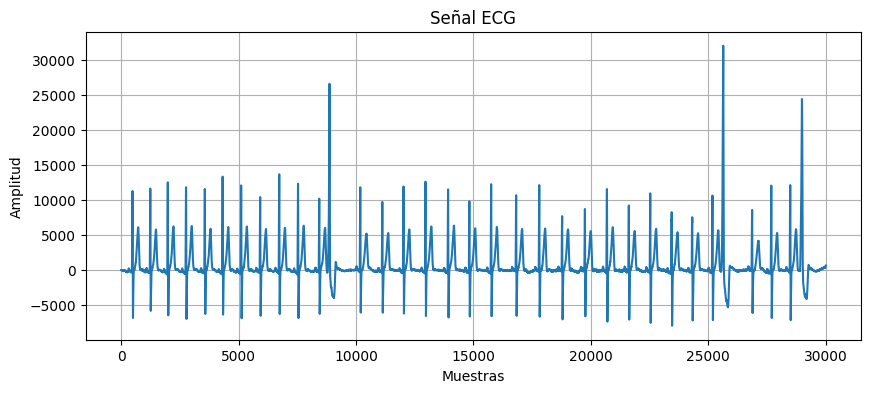

Cantidad de muestras ECG: 30000
Ancho de banda ECG: 22.50 Hz


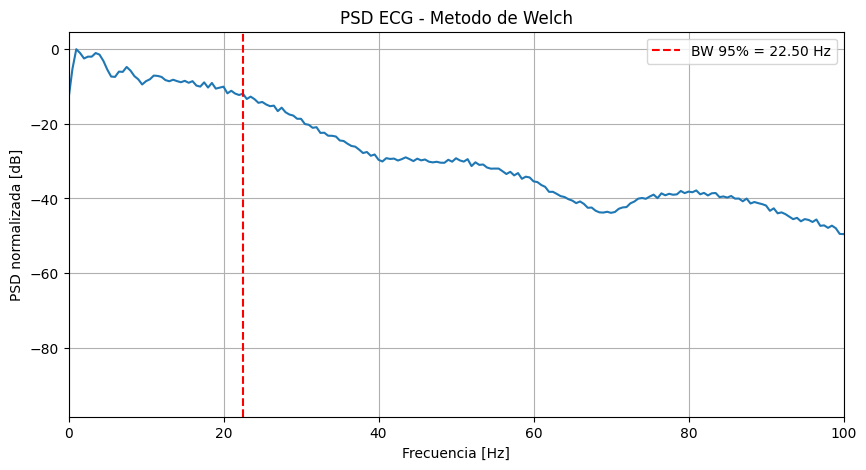

In [2]:
fs_ecg = 1000  # Hz

# Carga de la señal ECG
ecg_one_lead = np.load('ecg_sin_ruido.npy')
# ----- GRAFICO TEMPORAL -----

plt.figure(figsize=(10,4))

plt.plot(ecg_one_lead)

plt.title('Señal ECG')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')

plt.grid()
plt.show()

# Cantidad total de muestras
N_ecg = len(ecg_one_lead)

print('Cantidad de muestras ECG:', N_ecg)

# ----- METODO DE WELCH -----

# El método de Welch reduce la varianza
# del periodograma mediante el promedio
# de segmentos ventaneados.

nperseg_ecg = N_ecg // 15
noverlap_ecg = nperseg_ecg // 2

f_ecg, welch_ecg = sig.welch(
    ecg_one_lead,
    fs=fs_ecg,
    nperseg=nperseg_ecg,
    noverlap=noverlap_ecg
)

# ----- NORMALIZACION -----

# Se normaliza respecto al valor máximo
# para visualizar la PSD en dB.

welch_ecg_norm = welch_ecg / np.max(welch_ecg)

welch_ecg_db = 10 * np.log10(welch_ecg_norm)

# ----- ANCHO DE BANDA -----

# Se define el ancho de banda como la frecuencia
# que contiene el 95% de la energía total.

bw_ecg = calcular_bw(
    welch_ecg,
    f_ecg,
    porcentaje=0.95
)

print(f'Ancho de banda ECG: {bw_ecg:.2f} Hz')

# ----- GRAFICO -----

plt.figure(figsize=(10,5))

plt.plot(f_ecg, welch_ecg_db)

plt.axvline(
    x=bw_ecg,
    color='red',
    linestyle='--',
    label=f'BW 95% = {bw_ecg:.2f} Hz'
)

plt.title('PSD ECG - Metodo de Welch')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD normalizada [dB]')
plt.xlim(0, 100)
plt.grid()
plt.legend()

plt.show()

### Análisis de la ECG

La señal de electrocardiograma presenta un contenido espectral concentrado principalmente en bajas frecuencias.

En la PSD obtenida mediante el método de Welch puede observarse que la mayor parte de la energía se encuentra por debajo de los 40-50 Hz aproximadamente. Esto es esperable debido a como se comporta la actividad cardíaca.

El método de Welch permitió obtener una estimación espectral más suave y con menor varianza.

Además, el ancho de banda calculado utilizando el criterio del 95% de energía muestra que la información relevante del periodograma esta concentrada en un rango reducido de frecuencias.

### Pletismografia (PPG)

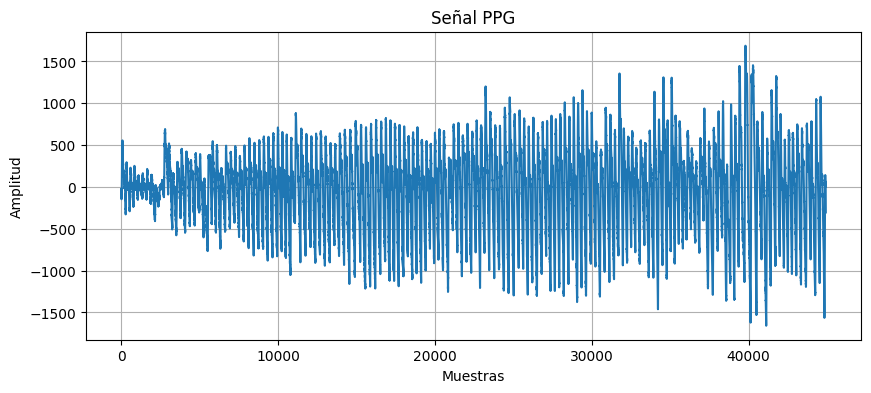

Cantidad de muestras PPG: 44919
Ancho de banda PPG: 4.01 Hz


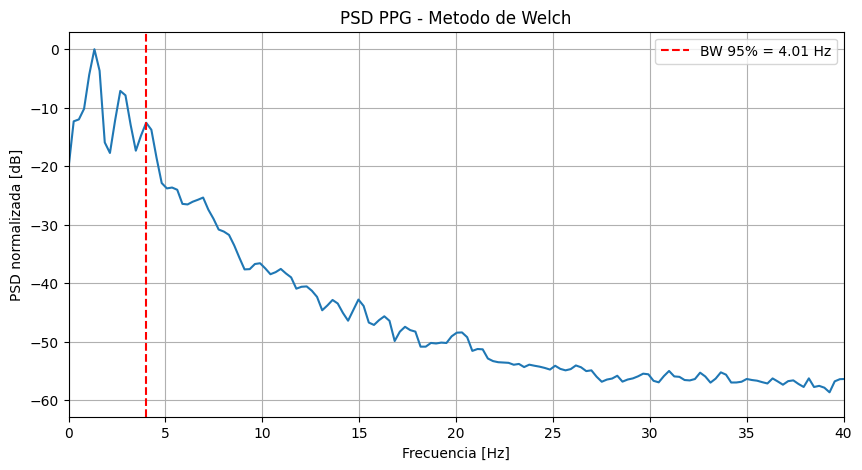

In [3]:
fs_ppg = 400  # Hz

# Carga de la señal PPG
ppg = np.load('ppg_sin_ruido.npy')

# ----- GRAFICO TEMPORAL -----

plt.figure(figsize=(10,4))

plt.plot(ppg)

plt.title('Señal PPG')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')

plt.grid()
plt.show()

# Cantidad de muestras
N_ppg = len(ppg)

print('Cantidad de muestras PPG:', N_ppg)

# ----- METODO DE WELCH -----

nperseg_ppg = N_ppg // 30
noverlap_ppg = nperseg_ppg // 2

f_ppg, welch_ppg = sig.welch(
    ppg,
    fs=fs_ppg,
    nperseg=nperseg_ppg,
    noverlap=noverlap_ppg
)



# ----- NORMALIZACION -----

welch_ppg_norm = welch_ppg / np.max(welch_ppg)

welch_ppg_db = 10 * np.log10(welch_ppg_norm)

# ----- ANCHO DE BANDA -----

bw_ppg = calcular_bw(
    welch_ppg,
    f_ppg,
    porcentaje=0.95
)

print(f'Ancho de banda PPG: {bw_ppg:.2f} Hz')

# ----- GRAFICO -----

plt.figure(figsize=(10,5))

plt.plot(f_ppg, welch_ppg_db)

plt.axvline(
    x=bw_ppg,
    color='red',
    linestyle='--',
    label=f'BW 95% = {bw_ppg:.2f} Hz'
)

plt.title('PSD PPG - Metodo de Welch')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD normalizada [dB]')
plt.xlim(0, 40)
plt.grid()
plt.legend()

plt.show()

### Análisis de la PPG
La señal de pletismografía (PPG) presenta un ancho de banda más reducido que el ECG. La mayor parte de la energía espectral esta concentrada en frecuencias bajas asociadas al ritmo cardíaco. La PSD mediante el método de Welch presenta una distribución angosta.

El ancho de banda obtenido confirma que la información útil de la señal se encuentra concentrada en un región espectral pequeña. 


### Audio- La cucaracha

Cantidad de muestras Audio: 144000


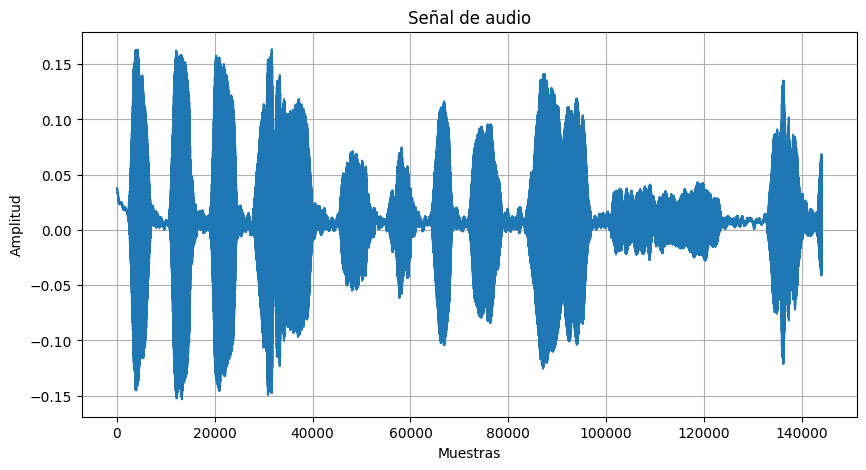

Ancho de banda Audio: 1500.00 Hz


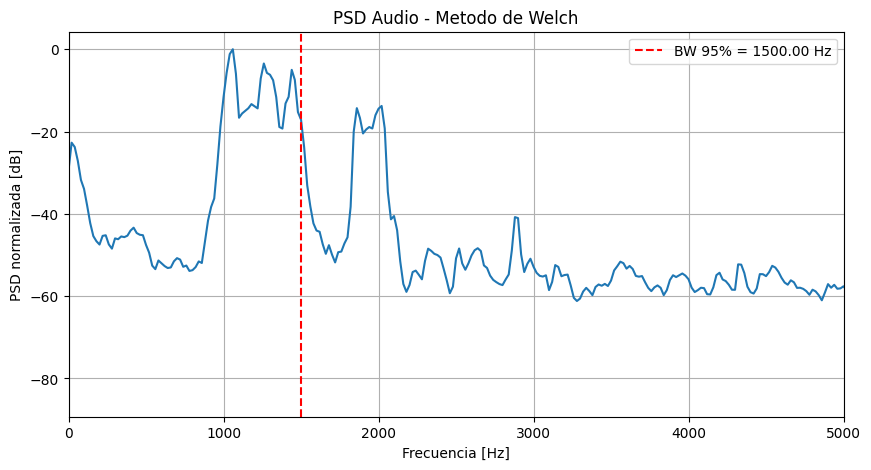

In [4]:
# Lectura del archivo de audio
fs_audio, wav_data = wavfile.read('la cucaracha.wav')

# Si el audio es estéreo,
# se toma solamente un canal.

if len(wav_data.shape) > 1:

    wav_data = wav_data[:,0]

# Cantidad de muestras
N_audio = len(wav_data)

print('Cantidad de muestras Audio:', N_audio)

# ----- GRAFICO TEMPORAL -----

plt.figure(figsize=(10,5))

plt.plot(wav_data)

plt.title('Señal de audio')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.grid()

plt.show()

# ----- METODO DE WELCH -----

nperseg_audio = N_audio // 60
noverlap_audio = nperseg_audio // 2

f_audio, welch_audio = sig.welch(
    wav_data,
    fs=fs_audio,
    nperseg=nperseg_audio,
    noverlap=noverlap_audio
)


# ----- NORMALIZACION -----

welch_audio_norm = welch_audio / np.max(welch_audio)

welch_audio_db = 10 * np.log10(welch_audio_norm)

# ----- ANCHO DE BANDA -----

bw_audio = calcular_bw(
    welch_audio,
    f_audio,
    porcentaje=0.95
)

print(f'Ancho de banda Audio: {bw_audio:.2f} Hz')

# ----- GRAFICO -----

plt.figure(figsize=(10,5))

plt.plot(f_audio, welch_audio_db)

plt.axvline(
    x=bw_audio,
    color='red',
    linestyle='--',
    label=f'BW 95% = {bw_audio:.2f} Hz'
)

plt.title('PSD Audio - Metodo de Welch')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD normalizada [dB]')
plt.xlim(0, 5000)
plt.grid()
plt.legend()

plt.show()

### Análisis del audio la cucaracha
La señal de audio presenta un comportamiento espectral considerablemente más amplio que las señales biomédicas analizadas anteriormente. 

En la PSD se observa energía distribuida sobre un rango grande de fecuencias debido a la presencia de múltiples componentes armónicas y variaciones temporales de la voz y la música.

A diferencia del ECG y del PPG, el audio constituye una señal de banda mucho más ancha, lo cual se refleja directamente en el valor del ancho de banda estimado.

### Audio Silbido

Cantidad de muestras Silbido: 144000


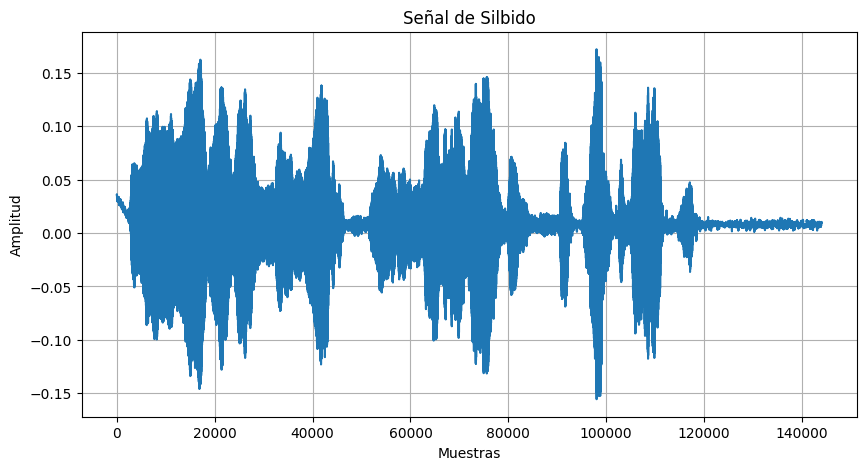

Ancho de banda Silbido: 6293.33 Hz


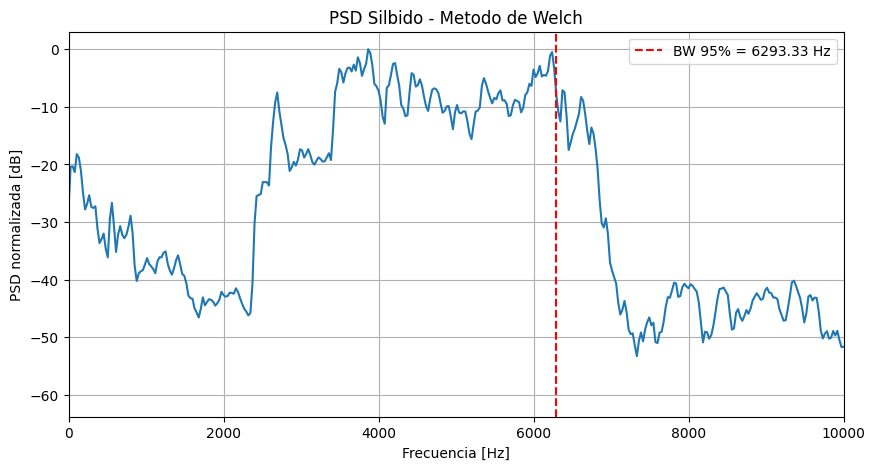

In [5]:
# Lectura del archivo de audio
fs_silbido, wav_silbido = wavfile.read('silbido.wav')

# Si el audio es estéreo,
# se utiliza solamente un canal.

if len(wav_silbido.shape) > 1:

    wav_silbido = wav_silbido[:,0]

# Cantidad de muestras
N_silbido = len(wav_silbido)

print('Cantidad de muestras Silbido:', N_silbido)

# ----- GRAFICO TEMPORAL -----

plt.figure(figsize=(10,5))

plt.plot(wav_silbido)

plt.title('Señal de Silbido')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')

plt.grid()

plt.show()

# ----- METODO DE WELCH -----

nperseg_silbido = N_silbido // 80
noverlap_silbido = nperseg_silbido // 2

f_silbido, welch_silbido = sig.welch(
    wav_silbido,
    fs=fs_silbido,
    nperseg=nperseg_silbido,
    noverlap=noverlap_silbido
)

# ----- NORMALIZACION -----

welch_silbido_norm = welch_silbido / np.max(welch_silbido)

# Conversión de PSD a dB
welch_silbido_db = 10 * np.log10(welch_silbido_norm)

# ----- ANCHO DE BANDA -----

bw_silbido = calcular_bw(
    welch_silbido,
    f_silbido,
    porcentaje=0.95
)

print(f'Ancho de banda Silbido: {bw_silbido:.2f} Hz')

# ----- GRAFICO -----

plt.figure(figsize=(10,5))

plt.plot(f_silbido, welch_silbido_db)

plt.axvline(
    x=bw_silbido,
    color='red',
    linestyle='--',
    label=f'BW 95% = {bw_silbido:.2f} Hz'
)

plt.title('PSD Silbido - Metodo de Welch')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD normalizada [dB]')

plt.xlim(0,10000)

plt.grid()
plt.legend()

plt.show()

### Análisis del audio silbido

La señal de silbido presenta un comportamiento espectral diferente al del audio de voz o música.

En este caso, gran parte de la energía se concentra alrededor de una frecuencia dominante, generando un espectro angosto similar al de una señal casi sinusoidal.

La PSD obtenida muestra un pico claramente definido y un ancho de banda menor respecto al audio anterior.

Esto permite identificar al silbido como una señal de banda relativamente angosta.

### Tabla de resumen 
A continuación se presentan los valores estimados de ancho de banda y varianza para cada una de las señales analizadas.

La comparación permite observar diferencias claras entre señales biomédicas y señales de audio, tanto en contenido frecuencial como en distribución energética.

In [6]:
print('\n')
print('================ TABLA RESUMEN ================')

print('\n')

print('ECG')
print(f'Fs: {fs_ecg} Hz')
print(f'Varianza: {np.var(ecg_one_lead):.4f}')
print(f'BW: {bw_ecg:.2f} Hz')

print('\n')

print('PPG')
print(f'Fs: {fs_ppg} Hz')
print(f'Varianza: {np.var(ppg):.4f}')
print(f'BW: {bw_ppg:.2f} Hz')

print('\n')

print('Audio')
print(f'Fs: {fs_audio} Hz')
print(f'Varianza: {np.var(wav_data):.4f}')
print(f'BW: {bw_audio:.2f} Hz')

print('\n')

print('Silbido')
print(f'Fs: {fs_silbido} Hz')
print(f'Varianza: {np.var(wav_silbido):.4f}')
print(f'BW: {bw_silbido:.2f} Hz')



================ TABLA RESUMEN ================


ECG
Fs: 1000 Hz
Varianza: 6940895.9293
BW: 22.50 Hz


PPG
Fs: 400 Hz
Varianza: 274671.4108
BW: 4.01 Hz


Audio
Fs: 48000 Hz
Varianza: 0.0018
BW: 1500.00 Hz


Silbido
Fs: 48000 Hz
Varianza: 0.0015
BW: 6293.33 Hz


### Conclusiones

En este trabajo se realizó la estimación de la densidad espectral de potencia de distintas señales reales utilizando el método de Welch.

Los resultados obtenidos permitieron comparar señales biomédicas y señales de audio observando diferencias significativas en sus contenidos espectrales.

Las señales ECG y PPG presentan espectros concentrados en bajas frecuencias y anchos de banda relativamente pequeños.

Por otro lado, la señal de audio presenta un espectro mucho más amplio debido a la presencia de múltiples componentes frecuenciales.

Finalmente, el silbido mostró un comportamiento espectral angosto, concentrando gran parte de su energía alrededor de una frecuencia dominante.

El método de Welch resultó adecuado para obtener estimaciones suaves de la PSD reduciendo la variabilidad espectral respecto al periodograma clásico.